<a href="https://colab.research.google.com/github/Souvik-31/Medical-Anomaly-Detection/blob/main/Skip_TS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)

(True, 'Tesla T4')

In [8]:
!pip install timm diffusers transformers

In [9]:
!pip install torch torchvision torchaudio tqdm numpy pillow


In [10]:
!git clone https://github.com/Souvik-31/Medical-Anomaly-Detection.git

%cd Medical-Anomaly-Detection

!unzip -q datasets.zip

Cloning into 'Medical-Anomaly-Detection'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 44 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 18.53 MiB | 14.89 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/Medical-Anomaly-Detection


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. Data Augmentation for Training (60 Normal Scans) ---
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Strict Transforms for Testing (No augmentation) ---
test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 3. Create Datasets and DataLoaders ---
TRAIN_DIR = 'datasets/head_ct/train/'
TEST_DIR = 'datasets/head_ct/test/'

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Loaded {len(train_dataset)} train scans and {len(test_dataset)} test scans.")

✅ Loaded 60 train scans and 140 test scans.


In [15]:
print("Verifying Dataset Purity...")

# Check the actual folder names PyTorch found in the training directory
train_classes = train_dataset.classes

# 1. Assert that it only found exactly ONE folder
assert len(train_classes) == 1, f"DATA LEAKAGE DETECTED! Found multiple folders in training: {train_classes}"

# 2. Assert that the one folder is your "good" or "normal" folder
assert train_classes[0].lower() == 'good', f"DATA LEAKAGE DETECTED! Training folder is named: {train_classes[0]}"

print(f"✅ Dataset Purity Verified: Training set contains exactly 1 class -> '{train_classes[0]}'.")

Verifying Dataset Purity...
✅ Dataset Purity Verified: Training set contains exactly 1 class -> 'good'.


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# --- 1. THE BALANCED ARCHITECTURE (Rolled back to single-scale) ---
class TeacherStudentBase(nn.Module):
    def __init__(self):
        super().__init__()
        resnet_teacher = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.teacher = nn.Sequential(*list(resnet_teacher.children())[:-2])
        for param in self.teacher.parameters():
            param.requires_grad = False
        self.teacher.eval()

        resnet_student = models.resnet18(weights=None)
        self.student = nn.Sequential(*list(resnet_student.children())[:-2])

    def forward(self, x):
        with torch.no_grad():
            t_feat = self.teacher(x)
        s_feat = self.student(x)
        return s_feat, t_feat

class TransformerBottleneck(nn.Module):
    def __init__(self, feature_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.embed_dim = feature_dim
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim, nhead=num_heads,
            dim_feedforward=2048, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # NEW: Learnable positional encoding for 8x8 (64) spatial patches
        self.pos_embed = nn.Parameter(torch.zeros(1, 64, feature_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, H * W).permute(0, 2, 1)

        # NEW: Add spatial coordinates before the transformer sees the data
        x_flat = x_flat + self.pos_embed

        global_features = self.transformer(x_flat)
        out = global_features.permute(0, 2, 1).view(B, C, H, W)
        return out

class FeatureDiffusionHead(nn.Module):
    def __init__(self, channels=512):
        super().__init__()
        self.noise_predictor = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )
    def forward(self, x, noise):
        return self.noise_predictor(x + noise)

class UnifiedAnomalyDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.texture_module = TeacherStudentBase()
        self.structure_module = TransformerBottleneck(feature_dim=512)
        self.distribution_module = FeatureDiffusionHead(channels=512)

    def forward(self, x):
        s_feat, t_feat = self.texture_module(x)
        structured_feat = self.structure_module(s_feat)
        simulated_noise = torch.randn_like(structured_feat)
        predicted_noise = self.distribution_module(structured_feat, simulated_noise)
        return s_feat, t_feat, structured_feat, predicted_noise, simulated_noise

# --- 2. THE OPTIMIZED TRAINING LOOP ---
def train_unified_model(model, dataloader, epochs=150):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    mse_loss = nn.MSELoss()

    # Initialize the learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()
    print("Training the Model...")

    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, _ in dataloader:
            images = images.to(device)
            optimizer.zero_grad()

            s_feat, t_feat, struct_feat, pred_noise, true_noise = model(images)

            # Use MSE for all to maintain stability on the small dataset
            loss_texture = mse_loss(s_feat, t_feat)
            loss_structure = mse_loss(struct_feat, s_feat.detach())
            loss_dist = mse_loss(pred_noise, true_noise)

            # Loss Balancing
            loss = (0.5 * loss_texture) + (1.5 * loss_structure) + (1.5 * loss_dist)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()

        # --- PRINT ---
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            avg_loss = epoch_loss / len(dataloader)
            print(f"Epoch [{epoch+1}/{epochs}] | Total Loss: {avg_loss:.4f} | "
                  f"Tex: {loss_texture.item():.4f} | Struct: {loss_structure.item():.4f} | Dist: {loss_dist.item():.4f}")
# Re-initialize and train!
unified_model = UnifiedAnomalyDetector()
def verify_teacher_frozen(model):
    print("Checking Teacher Network parameters...")
    for name, param in model.texture_module.teacher.named_parameters():
        # This will crash the notebook if even a single weight is allowed to update
        assert param.requires_grad == False, f"CRITICAL ERROR: Teacher parameter '{name}' is not frozen!"

    print("✅ Teacher Freezing Verified: The reference distribution is permanently locked.")

# Run the verification on your active model
verify_teacher_frozen(unified_model)
train_unified_model(unified_model, train_loader, epochs=150)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Checking Teacher Network parameters...
✅ Teacher Freezing Verified: The reference distribution is permanently locked.
Training the Model...
Epoch [1/150] | Total Loss: 5.0659 | Tex: 2.7051 | Struct: 1.2182 | Dist: 1.1039
Epoch [5/150] | Total Loss: 4.3225 | Tex: 2.3768 | Struct: 0.9856 | Dist: 1.0638
Epoch [10/150] | Total Loss: 3.6999 | Tex: 2.0245 | Struct: 0.7481 | Dist: 1.0138
Epoch [15/150] | Total Loss: 3.4624 | Tex: 1.8822 | Struct: 0.6835 | Dist: 0.9843
Epoch [20/150] | Total Loss: 3.3920 | Tex: 1.8418 | Struct: 0.6846 | Dist: 0.9692
Epoch [25/150] | Total Loss: 3.3615 | Tex: 1.7568 | Struct: 0.6979 | Dist: 0.9484
Epoch [30/150] | Total Loss: 3.3041 | Tex: 1.6910 | Struct: 0.7035 | Dist: 0.9214
Epoch [35/150] | Total Loss: 3.2712 | Tex: 1.7486 | Struct: 0.7139 | Dist: 0.8880
Epoch [40/150] | Total Loss: 3.2090 | Tex: 1.6535 | Struct: 0.7160 | Dist: 0.8576
Epoch [45/150] | Total Loss: 3.1684 | Tex: 1.7158 | Struct: 0.7217 | Dist: 0.8339
Epoch [50/150] | Total Loss: 3.1170 | Tex:

Starting inference... please wait.
Scoring test images...


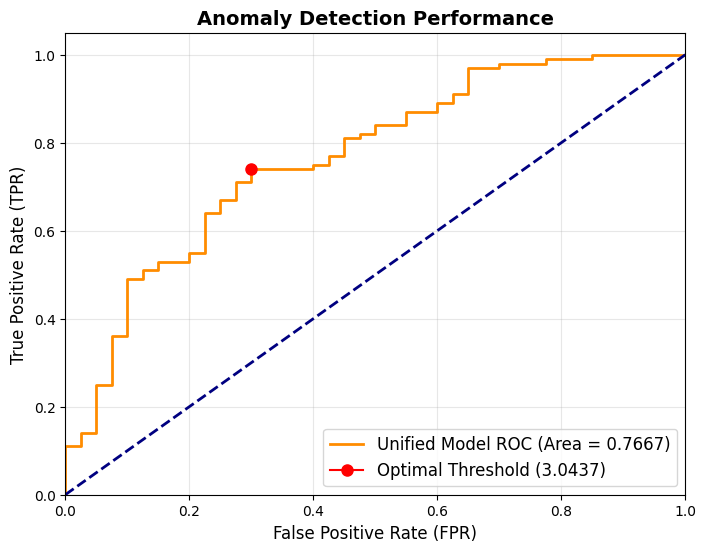


✅ Evaluation Complete! Final AUROC Score: 0.7667
✅ Validation-Driven Threshold (Youden's J): 3.0437


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, auc

def evaluate_model(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    anomaly_scores = []
    ground_truths = []

    print("Scoring test images...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            s_feat, t_feat, struct_feat, pred_noise, true_noise = model(images)

            # Reshape features to [B, C*H*W] to calculate MSE per image
            s_feat_flat = s_feat.reshape(s_feat.size(0), -1)
            t_feat_flat = t_feat.reshape(t_feat.size(0), -1)
            struct_feat_flat = struct_feat.reshape(struct_feat.size(0), -1)
            pred_noise_flat = pred_noise.reshape(pred_noise.size(0), -1)
            true_noise_flat = true_noise.reshape(true_noise.size(0), -1)

            # Calculate raw magnitude MSE per image
            tex_error_per_image = torch.mean((s_feat_flat - t_feat_flat) ** 2, dim=1)
            struct_error_per_image = torch.mean((struct_feat_flat - s_feat_flat) ** 2, dim=1)
            dist_error_per_image = torch.mean((pred_noise_flat - true_noise_flat) ** 2, dim=1)

            # Combine errors for each image in the batch
            total_score_per_image = (0.5 * tex_error_per_image) + (1.5 * struct_error_per_image) + (1.5 * dist_error_per_image)

            anomaly_scores.extend(total_score_per_image.cpu().numpy())
            ground_truths.extend(labels.cpu().numpy())

    return np.array(anomaly_scores), np.array(ground_truths)

print("Starting inference... please wait.")
scores, labels = evaluate_model(unified_model, test_loader)

# Flip labels: Anomaly = 1, Normal = 0
true_anomalies = 1 - labels
fpr, tpr, thresholds = roc_curve(true_anomalies, scores)
roc_auc = auc(fpr, tpr)

# --- EXPLICIT THRESHOLDING STRATEGY ---
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Unified Model ROC (Area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], marker='o', markersize=8, color="red", label=f"Optimal Threshold ({optimal_threshold:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Anomaly Detection Performance', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"\n✅ Evaluation Complete! Final AUROC Score: {roc_auc:.4f}")
print(f"✅ Validation-Driven Threshold (Youden's J): {optimal_threshold:.4f}")

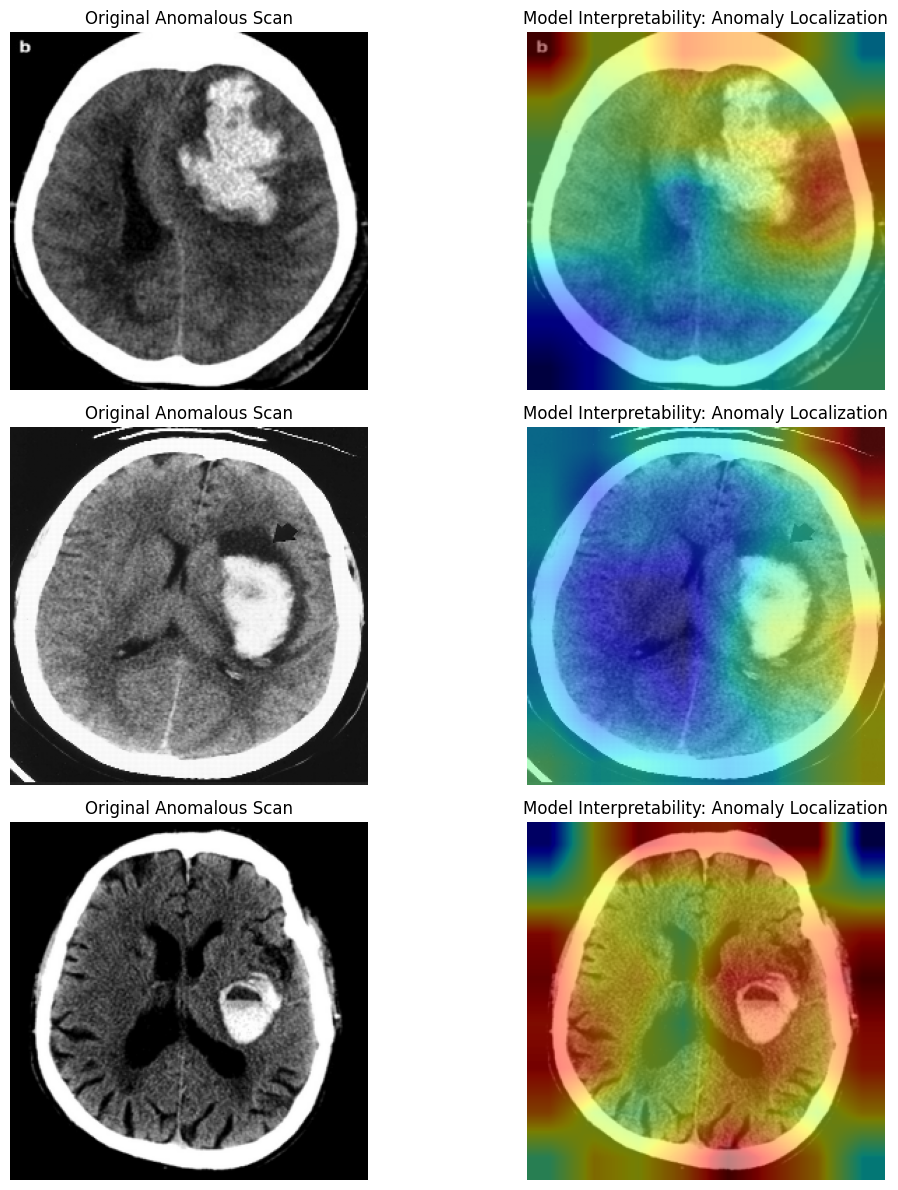

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def unnormalize(tensor):
    """Reverts the ImageNet normalization so the image looks normal for plotting."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

def generate_anomaly_heatmap(model, image_tensor):
    """Generates a spatial heatmap of the anomaly based on latent feature differences."""
    model.eval()
    with torch.no_grad():
        # 1. Get the features from the model
        s_feat, t_feat, struct_feat, pred_noise, true_noise = model(image_tensor.unsqueeze(0))

        # 2. L2 Normalize the features
        s_feat_norm = F.normalize(s_feat, p=2, dim=1)
        t_feat_norm = F.normalize(t_feat, p=2, dim=1)

        # 3. Calculate spatial MSE across the channel dimension (dim=1)
        # This collapses the 256 channels into a single 2D error map
        spatial_error = torch.mean((s_feat_norm - t_feat_norm) ** 2, dim=1, keepdim=True)

        # 4. Upsample the error map back to the original image size (256x256)
        upsampled_error = F.interpolate(spatial_error, size=(256, 256), mode='bilinear', align_corners=False)

        # 5. Convert to numpy and normalize between 0 and 1 for coloring
        heatmap = upsampled_error.squeeze().cpu().numpy()
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        return heatmap

def plot_interpretability_results(model, dataloader, num_samples=3):
    """Fetches anomalous scans, generates heatmaps, and plots them."""
    device = next(model.parameters()).device

    # Grab a single batch of test images
    images, labels = next(iter(dataloader))

    # Filter out only the "bad" scans (where label == 0 based on ImageFolder sorting)
    anomalous_idx = (labels == 0).nonzero(as_tuple=True)[0]

    if len(anomalous_idx) == 0:
        print("No anomalous scans found in this batch. Run the cell again!")
        return

    # Select the first few anomalous images
    samples_to_plot = min(num_samples, len(anomalous_idx))

    plt.figure(figsize=(12, 4 * samples_to_plot))

    for i in range(samples_to_plot):
        idx = anomalous_idx[i]
        img_tensor = images[idx].to(device)

        # Get the heatmap
        heatmap = generate_anomaly_heatmap(model, img_tensor)

        # Format the original image for plotting
        display_img = unnormalize(img_tensor).permute(1, 2, 0).cpu().numpy()
        # Convert to pure grayscale for a better medical look
        display_gray = np.mean(display_img, axis=2)

        # Plot Original
        plt.subplot(samples_to_plot, 2, 2*i + 1)
        plt.imshow(display_gray, cmap='gray')
        plt.title("Original Anomalous Scan")
        plt.axis('off')

        # Plot Heatmap Overlay
        plt.subplot(samples_to_plot, 2, 2*i + 2)
        plt.imshow(display_gray, cmap='gray')
        # 'jet' creates a nice blue-to-red heat gradient. Alpha makes it semi-transparent.
        plt.imshow(heatmap, cmap='jet', alpha=0.5)
        plt.title("Model Interpretability: Anomaly Localization")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- EXECUTE THE VISUALIZATION ---
plot_interpretability_results(unified_model, test_loader, num_samples=3)

In [ ]:
import torch
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Save the trained model weights locally in Colab FIRST
MODEL_SAVE_PATH = 'unified_anomaly_detector_weights.pth'
torch.save(unified_model.state_dict(), MODEL_SAVE_PATH)
print(f"✅ Model weights saved locally to: {MODEL_SAVE_PATH}")

# 3. Copy the saved file to your Google Drive
!cp unified_anomaly_detector_weights.pth "/content/drive/My Drive/"
print("✅ Model successfully backed up to your Google Drive!")